In [1]:
# Environment Setup and Dependencies
import subprocess
import sys

print("Installing required packages...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "protobuf==3.20.3", "-q"])
print("Protobuf configured for MediaPipe compatibility")

Installing required packages...
Protobuf configured for MediaPipe compatibility


In [2]:
# Import Libraries
import os
import sys
from glob import glob
import warnings
import json

import cv2
import numpy as np
from tqdm import tqdm

import mediapipe as mp

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Set random seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

e:\Tools\Miniconda\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


Libraries imported successfully
PyTorch version: 2.9.1+cpu
CUDA available: False


## Configuration

In [3]:
# Configuration Parameters
class Config:
    # Dataset
    DATA_ROOT = r"E:\College\Sem 6\Project\Computer Vision\Codes\Comp_data"
    FRAME_SKIP = 2
    MAX_FRAMES = 150
    
    # Model Architecture
    INPUT_CHANNELS = 3  # x, y, z coordinates
    GCN_HIDDEN_DIM = 128
    GCN_OUTPUT_DIM = 256
    TCN_CHANNELS = [256, 256, 512, 512]
    KERNEL_SIZE = 3
    DROPOUT = 0.3
    
    # Training
    BATCH_SIZE = 2
    LEARNING_RATE = 5e-4
    EPOCHS = 100
    WEIGHT_DECAY = 1e-4
    PATIENCE = 20
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = Config()
print(f"Configuration loaded")
print(f"Device: {config.DEVICE}")
print(f"GCN Hidden: {config.GCN_HIDDEN_DIM}, Output: {config.GCN_OUTPUT_DIM}")
print(f"TCN Channels: {config.TCN_CHANNELS}")

Configuration loaded
Device: cpu
GCN Hidden: 128, Output: 256
TCN Channels: [256, 256, 512, 512]


## Dataset Preparation

In [4]:
# Load Dataset and Create Label Mappings
video_paths = []
labels = []

for sentence_dir in sorted(os.listdir(config.DATA_ROOT)):
    sent_path = os.path.join(config.DATA_ROOT, sentence_dir)
    if not os.path.isdir(sent_path):
        continue
    for vp in glob(os.path.join(sent_path, "*.mp4")) + glob(os.path.join(sent_path, "*.MP4")):
        video_paths.append(vp)
        labels.append(sentence_dir)

unique_sentences = sorted(list(set(labels)))
label2id = {s: i for i, s in enumerate(unique_sentences)}
id2label = {i: s for s, i in label2id.items()}
numeric_labels = [label2id[s] for s in labels]

print(f"Dataset Statistics:")
print(f"Total videos: {len(video_paths)}")
print(f"Number of classes: {len(unique_sentences)}")
print(f"\nClass distribution:")
for sent, idx in label2id.items():
    count = labels.count(sent)
    print(f"  Class {idx}: {sent} - {count} videos")

Dataset Statistics:
Total videos: 86
Number of classes: 6

Class distribution:
  Class 0: are you free today - 14 videos
  Class 1: are you hiding something - 14 videos
  Class 2: bring water for me - 14 videos
  Class 3: can i help you - 16 videos
  Class 4: can you repeat that please - 14 videos
  Class 5: congratulations - 14 videos


## Graph Structure Definition

In [5]:
# Define Skeleton Graph Structure
def get_skeleton_graph():
    """
    Define graph adjacency for human skeleton
    Nodes: 33 pose landmarks + 21 left hand + 21 right hand = 75 nodes
    Edges: Natural body connections
    """
    # Pose connections (MediaPipe pose landmark indices)
    pose_edges = [
        # Face
        (0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8),
        # Upper body
        (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21),
        (12, 14), (14, 16), (16, 18), (16, 20), (16, 22),
        # Torso
        (11, 23), (12, 24), (23, 24),
        # Lower body
        (23, 25), (25, 27), (27, 29), (29, 31),
        (24, 26), (26, 28), (28, 30), (30, 32)
    ]
    
    # Left hand connections (offset by 33)
    left_hand_base = 33
    hand_edges = [
        (0, 1), (1, 2), (2, 3), (3, 4),  # Thumb
        (0, 5), (5, 6), (6, 7), (7, 8),  # Index
        (0, 9), (9, 10), (10, 11), (11, 12),  # Middle
        (0, 13), (13, 14), (14, 15), (15, 16),  # Ring
        (0, 17), (17, 18), (18, 19), (19, 20),  # Pinky
        (5, 9), (9, 13), (13, 17)  # Palm connections
    ]
    left_hand_edges = [(u + left_hand_base, v + left_hand_base) for u, v in hand_edges]
    
    # Right hand connections (offset by 54)
    right_hand_base = 54
    right_hand_edges = [(u + right_hand_base, v + right_hand_base) for u, v in hand_edges]
    
    # Connect hands to wrists (pose landmarks 15 and 16)
    hand_to_body_edges = [(15, left_hand_base), (16, right_hand_base)]
    
    # Combine all edges
    all_edges = pose_edges + left_hand_edges + right_hand_edges + hand_to_body_edges
    
    # Create adjacency matrix
    num_nodes = 75  # 33 + 21 + 21
    adjacency = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    
    for u, v in all_edges:
        adjacency[u, v] = 1
        adjacency[v, u] = 1
    
    # Add self-loops
    adjacency += np.eye(num_nodes)
    
    return torch.from_numpy(adjacency)

# Create adjacency matrix
adjacency_matrix = get_skeleton_graph()
print(f"Graph structure created")
print(f"Number of nodes: {adjacency_matrix.shape[0]}")
print(f"Number of edges: {(adjacency_matrix.sum().item() - adjacency_matrix.shape[0]) // 2:.0f}")

Graph structure created
Number of nodes: 75
Number of edges: 79


## Feature Extraction

In [6]:
# MediaPipe Keypoint Extraction
mp_holistic = mp.solutions.holistic

def extract_keypoints_from_frame(results):
    """
    Extract 75 keypoints: 33 pose + 21 left hand + 21 right hand
    Each keypoint has 3 features: x, y, z
    Returns: [75, 3] array
    """
    keypoints = np.zeros((75, 3), dtype=np.float32)
    
    # Pose landmarks (0-32)
    if results.pose_landmarks:
        for i, lm in enumerate(results.pose_landmarks.landmark):
            keypoints[i] = [lm.x, lm.y, lm.z]
    
    # Left hand landmarks (33-53)
    if results.left_hand_landmarks:
        for i, lm in enumerate(results.left_hand_landmarks.landmark):
            keypoints[33 + i] = [lm.x, lm.y, lm.z]
    
    # Right hand landmarks (54-74)
    if results.right_hand_landmarks:
        for i, lm in enumerate(results.right_hand_landmarks.landmark):
            keypoints[54 + i] = [lm.x, lm.y, lm.z]
    
    return keypoints

print("Keypoint extraction function initialized")
print("Output shape per frame: [75 nodes, 3 features]")

Keypoint extraction function initialized
Output shape per frame: [75 nodes, 3 features]


In [7]:
#No2
# Eigenvalue-Based Keypoint Selector
class EigenKeypointSelector:

    def __init__(self, n_components=35, variance_threshold=0.95):
        self.n_components = n_components
        self.variance_threshold = variance_threshold
        self.selected_indices = None
        self.keypoint_variances = None
        self.eigenvalues = None
        self.explained_variance_ratio = None
        
    def fit(self, video_paths, frame_skip=2, max_videos=None):    
        all_keypoints = []
        max_videos = max_videos or len(video_paths)
        
        with mp_holistic.Holistic(
            static_image_mode=False,
            model_complexity=1,
            enable_segmentation=False,
            refine_face_landmarks=False
        ) as holistic:
            for video_path in tqdm(video_paths[:max_videos], desc="Processing videos"):
                try:
                    cap = cv2.VideoCapture(video_path)
                    if not cap.isOpened():
                        continue
                    
                    frame_idx = 0
                    while True:
                        ret, frame = cap.read()
                        if not ret:
                            break
                        
                        if frame_idx % frame_skip != 0:
                            frame_idx += 1
                            continue
                        
                        # Process frame
                        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                        image.flags.writeable = False
                        results = holistic.process(image)
                        
                        # Extract keypoints
                        keypoints = extract_keypoints_from_frame(results)
                        all_keypoints.append(keypoints)
                        
                        frame_idx += 1
                    
                    cap.release()
                except Exception as e:
                    print(f"Error processing {video_path}: {e}")
                    continue
        
        # Convert to numpy array: [num_frames, 75, 3]
        all_keypoints = np.array(all_keypoints)
        print(f"Collected {all_keypoints.shape[0]} frames from {max_videos} videos")
        
        # Flatten each keypoint's 3D coordinates into single value per keypoint
        # We'll compute variance across all coordinates for each keypoint
        # Shape: [num_frames, 75, 3] -> [num_frames, 75*3]
        flattened = all_keypoints.reshape(all_keypoints.shape[0], -1)
        
        # Compute per-keypoint variance
        # Reshape to [num_frames, 75 keypoints, 3 coords]
        keypoint_data = all_keypoints.reshape(-1, 75, 3)
        
        # Compute variance for each keypoint (across all frames and coordinates)
        # We measure how much each keypoint moves
        keypoint_variances = np.zeros(75)
        for i in range(75):
            # Variance of x, y, z movements for keypoint i
            keypoint_variances[i] = np.var(keypoint_data[:, i, :])
        
        self.keypoint_variances = keypoint_variances
        
        # Sort keypoints by variance (descending)
        sorted_indices = np.argsort(keypoint_variances)[::-1]
        
        # Select top-k keypoints with highest variance
        self.selected_indices = sorted_indices[:self.n_components]
        self.selected_indices = np.sort(self.selected_indices)  # Sort for consistency
        
        # Compute eigenvalues (normalized variances)
        total_variance = np.sum(keypoint_variances)
        self.eigenvalues = keypoint_variances[sorted_indices]
        self.explained_variance_ratio = self.eigenvalues / total_variance
        
        print(f"\n✓ Keypoint Selection Complete")
        print(f"  - Original keypoints: 75")
        print(f"  - Selected keypoints: {self.n_components}")
        print(f"  - Variance explained: {self.explained_variance_ratio[:self.n_components].sum():.2%}")
        print(f"  - Top 5 most dynamic keypoints: {self.selected_indices[:5].tolist()}")
        
        return self
    
    def transform(self, keypoints):
        if self.selected_indices is None:
            raise ValueError("Must call fit() before transform()")
        
        if keypoints.ndim == 3:
            # [T, 75, 3] -> [T, n_components, 3]
            return keypoints[:, self.selected_indices, :]
        elif keypoints.ndim == 2:
            # [75, 3] -> [n_components, 3]
            return keypoints[self.selected_indices, :]
        else:
            raise ValueError(f"Expected 2D or 3D array, got {keypoints.ndim}D")
    
    def get_keypoint_labels(self):
        pose_landmarks = [
            "Nose", "Left Eye Inner", "Left Eye", "Left Eye Outer", "Right Eye Inner",
            "Right Eye", "Right Eye Outer", "Left Ear", "Right Ear", "Mouth Left",
            "Mouth Right", "Left Shoulder", "Right Shoulder", "Left Elbow", "Right Elbow",
            "Left Wrist", "Right Wrist", "Left Pinky", "Right Pinky", "Left Index",
            "Right Index", "Left Thumb", "Right Thumb", "Left Hip", "Right Hip",
            "Left Knee", "Right Knee", "Left Ankle", "Right Ankle", "Left Heel",
            "Right Heel", "Left Foot Index", "Right Foot Index"
        ]
        
        hand_landmarks = [
            "Wrist", "Thumb CMC", "Thumb MCP", "Thumb IP", "Thumb Tip",
            "Index MCP", "Index PIP", "Index DIP", "Index Tip",
            "Middle MCP", "Middle PIP", "Middle DIP", "Middle Tip",
            "Ring MCP", "Ring PIP", "Ring DIP", "Ring Tip",
            "Pinky MCP", "Pinky PIP", "Pinky DIP", "Pinky Tip"
        ]
        
        all_labels = (
            pose_landmarks +
            [f"Left Hand {lm}" for lm in hand_landmarks] +
            [f"Right Hand {lm}" for lm in hand_landmarks]
        )
        
        if self.selected_indices is not None:
            return [all_labels[i] for i in self.selected_indices]
        return all_labels
    
    def visualize_selection(self):
        if self.keypoint_variances is None:
            raise ValueError("Must call fit() before visualize()")
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # 1. Variance per keypoint
        ax = axes[0, 0]
        ax.bar(range(75), self.keypoint_variances, alpha=0.6, label='All keypoints')
        ax.bar(self.selected_indices, self.keypoint_variances[self.selected_indices],
               alpha=0.8, color='red', label='Selected keypoints')
        ax.set_xlabel('Keypoint Index')
        ax.set_ylabel('Variance')
        ax.set_title('Keypoint Variance Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 2. Cumulative explained variance
        ax = axes[0, 1]
        cumsum = np.cumsum(self.explained_variance_ratio)
        ax.plot(range(1, len(cumsum)+1), cumsum, marker='o', markersize=3)
        ax.axvline(self.n_components, color='red', linestyle='--', 
                   label=f'Selected: {self.n_components} keypoints')
        ax.axhline(cumsum[self.n_components-1], color='green', linestyle='--',
                   label=f'Variance: {cumsum[self.n_components-1]:.2%}')
        ax.set_xlabel('Number of Keypoints')
        ax.set_ylabel('Cumulative Explained Variance')
        ax.set_title('Cumulative Variance Explained')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 3. Top 20 most dynamic keypoints
        ax = axes[1, 0]
        top_20_indices = np.argsort(self.keypoint_variances)[::-1][:20]
        top_20_variances = self.keypoint_variances[top_20_indices]
        labels = self.get_keypoint_labels()
        top_20_labels = [labels[i] if i in self.selected_indices else f"[{i}]" 
                        for i in top_20_indices]
        
        colors = ['red' if i in self.selected_indices else 'gray' for i in top_20_indices]
        ax.barh(range(20), top_20_variances, color=colors, alpha=0.7)
        ax.set_yticks(range(20))
        ax.set_yticklabels(top_20_labels, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel('Variance')
        ax.set_title('Top 20 Most Dynamic Keypoints')
        ax.grid(True, alpha=0.3, axis='x')
        
        # 4. Keypoint distribution by body part
        ax = axes[1, 1]
        pose_selected = np.sum(self.selected_indices < 33)
        left_hand_selected = np.sum((self.selected_indices >= 33) & (self.selected_indices < 54))
        right_hand_selected = np.sum(self.selected_indices >= 54)
        
        parts = ['Pose\n(33)', 'Left Hand\n(21)', 'Right Hand\n(21)']
        selected = [pose_selected, left_hand_selected, right_hand_selected]
        total = [33, 21, 21]
        
        x = np.arange(len(parts))
        width = 0.35
        
        ax.bar(x - width/2, total, width, label='Total', alpha=0.5)
        ax.bar(x + width/2, selected, width, label='Selected', alpha=0.8)
        ax.set_ylabel('Number of Keypoints')
        ax.set_title('Selected Keypoints by Body Part')
        ax.set_xticks(x)
        ax.set_xticklabels(parts)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nBody Part Distribution:")
        print(f"  Pose: {pose_selected}/33 ({pose_selected/33:.1%})")
        print(f"  Left Hand: {left_hand_selected}/21 ({left_hand_selected/21:.1%})")
        print(f"  Right Hand: {right_hand_selected}/21 ({right_hand_selected/21:.1%})")

print("EigenKeypointSelector class defined")
print("Ready to analyze and select most informative keypoints")

EigenKeypointSelector class defined
Ready to analyze and select most informative keypoints


## Dataset Class

In [11]:
# Dataset Class with Graph Structure
class SignLanguageGraphDataset(Dataset):
    def __init__(self, video_paths, labels, frame_skip=2, augment=False):
        self.video_paths = video_paths
        self.labels = labels
        self.frame_skip = frame_skip
        self.augment = augment
    
    def __len__(self):
        return len(self.video_paths)
    
    def extract_skeleton_sequence(self, video_path):
        """Extract skeleton sequence from video"""
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError(f"Cannot open video: {video_path}")
        
        skeleton_seq = []
        frame_idx = 0
        
        with mp_holistic.Holistic(
            static_image_mode=False,
            model_complexity=1,
            enable_segmentation=False,
            refine_face_landmarks=False
        ) as holistic:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                if frame_idx % self.frame_skip != 0:
                    frame_idx += 1
                    continue
                
                # Process frame
                image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                image.flags.writeable = False
                results = holistic.process(image)
                
                # Extract keypoints
                keypoints = extract_keypoints_from_frame(results)
                skeleton_seq.append(keypoints)
                frame_idx += 1
        
        cap.release()
        
        if len(skeleton_seq) == 0:
            raise ValueError(f"No keypoints extracted from: {video_path}")
        
        return np.stack(skeleton_seq)  # [T, 75, 3]
    
    def augment_sequence(self, seq):
        """Apply augmentation to skeleton sequence"""
        # Spatial: Add random noise
        if np.random.rand() < 0.5:
            noise = np.random.normal(0, 0.01, seq.shape)
            seq = seq + noise
        
        # Temporal: Random subsampling
        if np.random.rand() < 0.3 and len(seq) > 20:
            keep_ratio = np.random.uniform(0.8, 0.95)
            indices = sorted(np.random.choice(len(seq), size=int(len(seq) * keep_ratio), replace=False))
            seq = seq[indices]
        
        # Spatial: Random scaling
        if np.random.rand() < 0.4:
            scale = np.random.uniform(0.95, 1.05)
            seq = seq * scale
        
        return seq
    
    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]
        
        try:
            skeleton_seq = self.extract_skeleton_sequence(video_path)
        except Exception as e:
            print(f"Error processing {video_path}: {e}")
            skeleton_seq = np.zeros((10, 75, 3), dtype=np.float32)
        
        # Augmentation
        if self.augment:
            skeleton_seq = self.augment_sequence(skeleton_seq)
        
        # Normalize to [-1, 1]
        skeleton_seq = (skeleton_seq - 0.5) * 2.0
        skeleton_seq = skeleton_seq.astype(np.float32)
        
        return skeleton_seq, label

print("Dataset class created")
print("Output format: [Time, Nodes, Features] = [T, 75, 3]")

Dataset class created
Output format: [Time, Nodes, Features] = [T, 75, 3]


In [13]:
# Create Train/Validation Split
train_indices, val_indices = train_test_split(
    range(len(video_paths)),
    test_size=0.2,
    random_state=SEED,
    stratify=numeric_labels
)

train_dataset = SignLanguageGraphDataset(
    [video_paths[i] for i in train_indices],
    [numeric_labels[i] for i in train_indices],
    frame_skip=config.FRAME_SKIP,
    augment=True
)

val_dataset = SignLanguageGraphDataset(
    [video_paths[i] for i in val_indices],
    [numeric_labels[i] for i in val_indices],
    frame_skip=config.FRAME_SKIP,
    augment=False
)

print(f"Dataset split completed")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Dataset split completed
Training samples: 68
Validation samples: 18



EIGENVALUE-BASED KEYPOINT SELECTION


Processing videos: 100%|██████████| 68/68 [02:35<00:00,  2.29s/it]


Collected 2764 frames from 68 videos

✓ Keypoint Selection Complete
  - Original keypoints: 75
  - Selected keypoints: 35
  - Variance explained: 78.02%
  - Top 5 most dynamic keypoints: [0, 1, 2, 3, 4]


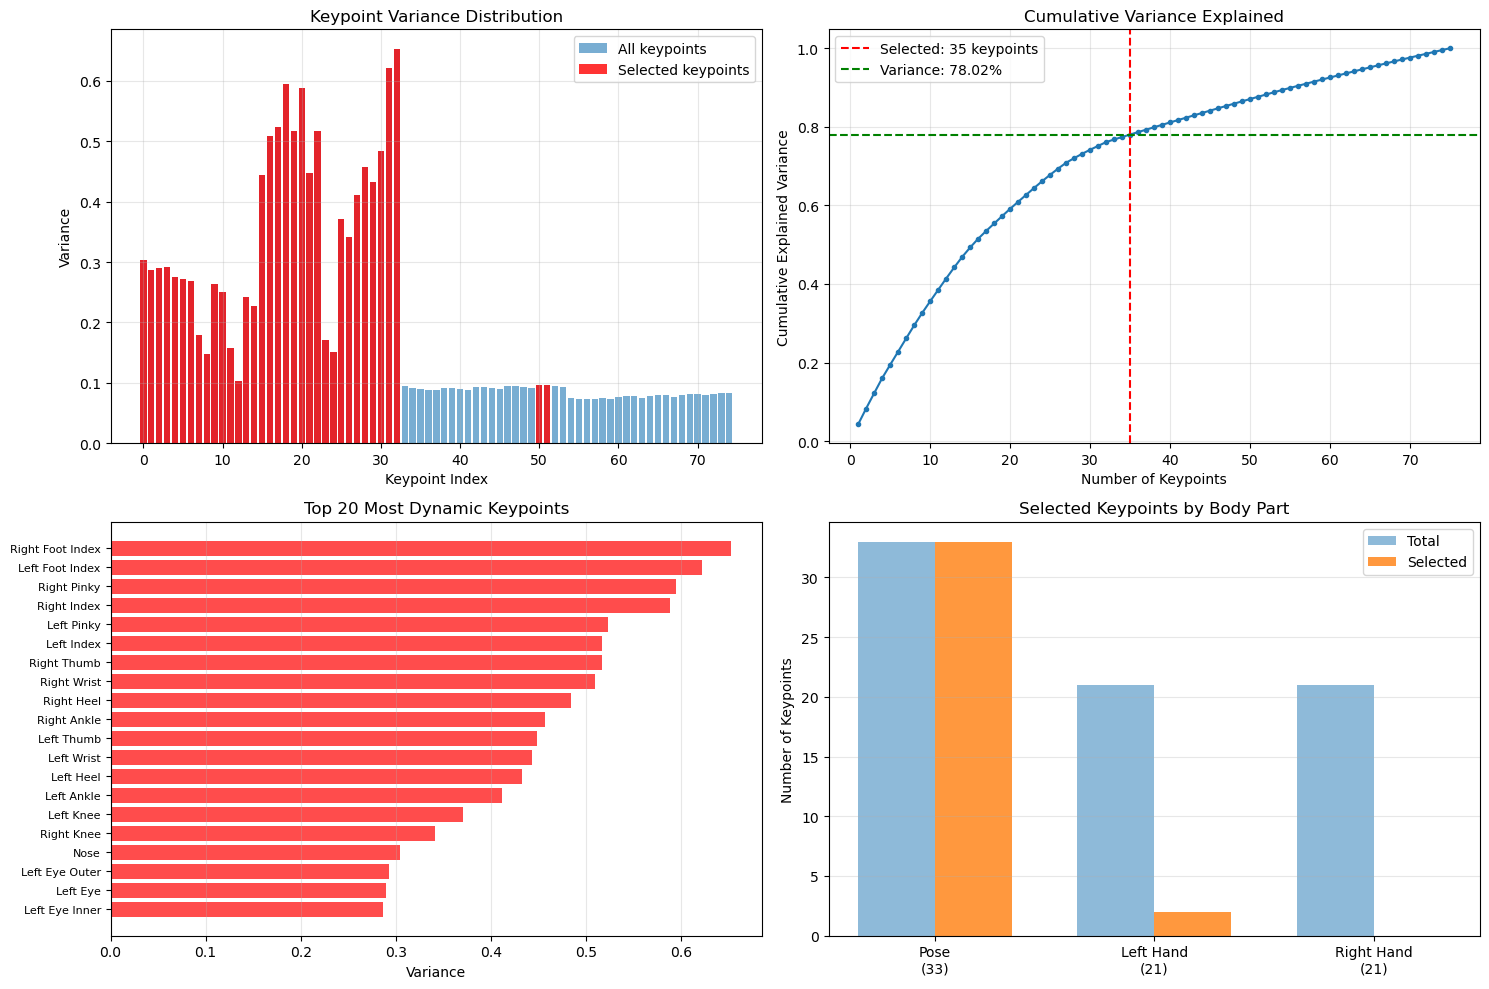


Body Part Distribution:
  Pose: 33/33 (100.0%)
  Left Hand: 2/21 (9.5%)
  Right Hand: 0/21 (0.0%)

 Selected Keypoint Indices (35):
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 50, 51]

Top 10 Most Important Keypoints:
   1. [ 0] Nose                           - Variance: 0.303949
   2. [ 1] Left Eye Inner                 - Variance: 0.286064
   3. [ 2] Left Eye                       - Variance: 0.289454
   4. [ 3] Left Eye Outer                 - Variance: 0.292530
   5. [ 4] Right Eye Inner                - Variance: 0.274569
   6. [ 5] Right Eye                      - Variance: 0.271667
   7. [ 6] Right Eye Outer                - Variance: 0.269325
   8. [ 7] Left Ear                       - Variance: 0.179111
   9. [ 8] Right Ear                      - Variance: 0.148243
  10. [ 9] Mouth Left                     - Variance: 0.264156


In [14]:
#No2
# Perform Eigenvalue-Based Keypoint Selection
print("\n" + "="*80)
print("EIGENVALUE-BASED KEYPOINT SELECTION")
print("="*80)

eigen_selector = EigenKeypointSelector(
    n_components=35,  # Select 35 out of 75 keypoints (~47% reduction)
    variance_threshold=0.95
)

# Fit on training videos
train_video_paths = [video_paths[i] for i in train_indices]
eigen_selector.fit(train_video_paths, frame_skip=config.FRAME_SKIP, max_videos=len(train_video_paths))

# Visualize results
eigen_selector.visualize_selection()

# Print selected keypoints
print(f"\n Selected Keypoint Indices ({len(eigen_selector.selected_indices)}):")
print(eigen_selector.selected_indices.tolist())
print(f"\nTop 10 Most Important Keypoints:")
for i, (idx, name) in enumerate(zip(eigen_selector.selected_indices[:10], eigen_selector.get_keypoint_labels()[:10])):
    variance = eigen_selector.keypoint_variances[idx]
    print(f"  {i+1:2d}. [{idx:2d}] {name:30s} - Variance: {variance:.6f}")

In [15]:
#No2
# Rebuild Graph Structure for Selected Keypoints
def rebuild_adjacency_for_selected_keypoints(selected_indices, original_adjacency):
    """
    Build new adjacency matrix for selected keypoints only.
    Maintains connectivity between selected keypoints.
    """
    n_selected = len(selected_indices)
    
    # Extract submatrix for selected keypoints
    new_adjacency = original_adjacency[selected_indices][:, selected_indices]
    
    # Ensure connectivity: if a keypoint becomes isolated, connect to nearest neighbors
    for i in range(n_selected):
        if new_adjacency[i].sum() == 1:  # Only self-loop
            for j in range(n_selected):
                if i != j:
                    new_adjacency[i, j] = 1
                    new_adjacency[j, i] = 1
                    break
    
    return new_adjacency

# Rebuild adjacency matrix for selected keypoints
reduced_adjacency = rebuild_adjacency_for_selected_keypoints(
    eigen_selector.selected_indices,
    adjacency_matrix
)

print(f"\nGraph structure rebuilt for selected keypoints")
print(f"  Original graph: {adjacency_matrix.shape[0]} nodes, {(adjacency_matrix.sum().item() - adjacency_matrix.shape[0]) // 2:.0f} edges")
print(f"  Reduced graph: {reduced_adjacency.shape[0]} nodes, {(reduced_adjacency.sum().item() - reduced_adjacency.shape[0]) // 2:.0f} edges")
print(f"  Node reduction: {(1 - reduced_adjacency.shape[0]/adjacency_matrix.shape[0]):.1%}")


Graph structure rebuilt for selected keypoints
  Original graph: 75 nodes, 79 edges
  Reduced graph: 35 nodes, 32 edges
  Node reduction: 53.3%


In [16]:
# Collate Function for Variable-Length Sequences
def collate_fn(batch):
    """Pad sequences to max length in batch"""
    sequences, labels = zip(*batch)
    lengths = [s.shape[0] for s in sequences]
    max_len = max(lengths)
    
    # Pad: [T, 75, 3]
    padded = np.zeros((len(sequences), max_len, 75, 3), dtype=np.float32)
    for i, seq in enumerate(sequences):
        padded[i, :seq.shape[0]] = seq
    
    padded_tensor = torch.from_numpy(padded)
    lengths_tensor = torch.tensor(lengths, dtype=torch.long)
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    
    return padded_tensor, lengths_tensor, labels_tensor

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

print(f"DataLoaders created")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

DataLoaders created
Training batches: 34
Validation batches: 9


## Model Architecture

In [17]:
# Graph Convolutional Layer
class GraphConvolution(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
    
    def forward(self, x, adjacency):
        """
        Args:
            x: [B, T, N, C] - batch, time, nodes, channels
            adjacency: [N, N] - adjacency matrix
        Returns:
            [B, T, N, C']
        """
        B, T, N, C = x.shape
        
        # Compute degree matrix for normalization
        degree = adjacency.sum(dim=1, keepdim=True)
        degree = degree.pow(-0.5)
        degree[torch.isinf(degree)] = 0
        
        # Symmetric normalization: D^-0.5 * A * D^-0.5
        norm_adj = degree * adjacency * degree.t()
        
        # Reshape for batch processing
        x_flat = x.reshape(B * T, N, C)
        
        # Graph convolution: X' = A_norm * X * W
        x_conv = torch.matmul(norm_adj, x_flat)  # [B*T, N, C]
        x_conv = self.linear(x_conv)  # [B*T, N, C']
        
        # Batch normalization
        x_conv = x_conv.reshape(B * T * N, -1)
        x_conv = self.bn(x_conv)
        x_conv = x_conv.reshape(B, T, N, -1)
        
        return F.relu(x_conv)

print("Graph Convolutional Layer defined")

Graph Convolutional Layer defined


In [12]:
# Spatial Graph Convolutional Network
class SpatialGCN(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_dim, dropout=0.3):
        super().__init__()
        self.gc1 = GraphConvolution(in_channels, hidden_dim)
        self.gc2 = GraphConvolution(hidden_dim, out_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, adjacency):
        """
        Args:
            x: [B, T, N, C] where C=3 (x, y, z)
            adjacency: [N, N]
        Returns:
            [B, T, C'] where C' is feature dimension per frame
        """
        # Apply graph convolutions
        x = self.gc1(x, adjacency)
        x = self.dropout(x)
        x = self.gc2(x, adjacency)  # [B, T, N, out_dim]
        
        # Global pooling over nodes
        x = x.mean(dim=2)  # [B, T, out_dim]
        
        return x

print("Spatial GCN module defined")

Spatial GCN module defined


In [13]:
# Temporal Convolutional Block with Residual Connection
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.3):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        
        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.dropout1 = nn.Dropout(dropout)
        
        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout2 = nn.Dropout(dropout)
        
        # Residual connection
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        
    def forward(self, x):
        """
        Args:
            x: [B, C, T]
        Returns:
            [B, C', T]
        """
        residual = x
        
        # First conv block
        out = self.conv1(x)
        out = out[:, :, :x.size(2)]  # Remove padding
        out = self.bn1(out)
        out = F.relu(out)
        out = self.dropout1(out)
        
        # Second conv block
        out = self.conv2(out)
        out = out[:, :, :x.size(2)]  # Remove padding
        out = self.bn2(out)
        out = F.relu(out)
        out = self.dropout2(out)
        
        # Residual connection
        if self.downsample is not None:
            residual = self.downsample(residual)
        
        return F.relu(out + residual)

print("Temporal Block with residual connection defined")

Temporal Block with residual connection defined


In [14]:
# Temporal Convolutional Network
class TemporalCN(nn.Module):
    def __init__(self, in_channels, channel_list, kernel_size=3, dropout=0.3):
        super().__init__()
        layers = []
        num_levels = len(channel_list)
        
        for i in range(num_levels):
            dilation = 2 ** i
            in_ch = in_channels if i == 0 else channel_list[i-1]
            out_ch = channel_list[i]
            
            layers.append(
                TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout)
            )
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        Args:
            x: [B, T, C]
        Returns:
            [B, T, C']
        """
        x = x.transpose(1, 2)  # [B, C, T]
        x = self.network(x)  # [B, C', T]
        x = x.transpose(1, 2)  # [B, T, C']
        return x

print("Temporal Convolutional Network defined")

Temporal Convolutional Network defined


In [15]:
# Complete GCN-TCN Hybrid Model
class GCNTCN_SignLanguageClassifier(nn.Module):
    def __init__(self, adjacency, input_channels, gcn_hidden, gcn_output, 
                 tcn_channels, num_classes, kernel_size=3, dropout=0.3):
        super().__init__()
        
        # Register adjacency matrix as buffer
        self.register_buffer('adjacency', adjacency)
        
        # Spatial GCN for skeleton structure
        self.spatial_gcn = SpatialGCN(input_channels, gcn_hidden, gcn_output, dropout)
        
        # Temporal TCN for sequence modeling
        self.temporal_tcn = TemporalCN(gcn_output, tcn_channels, kernel_size, dropout)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(tcn_channels[-1], 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x, lengths):
        """
        Args:
            x: [B, T, N, C] - batch, time, nodes, channels
            lengths: [B] - actual sequence lengths
        Returns:
            [B, num_classes]
        """
        B, T, N, C = x.shape
        
        # Spatial modeling with GCN
        x = self.spatial_gcn(x, self.adjacency)  # [B, T, gcn_output]
        
        # Temporal modeling with TCN
        x = self.temporal_tcn(x)  # [B, T, tcn_channels[-1]]
        
        # Temporal pooling with masking
        mask = torch.arange(T, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
        mask = mask.unsqueeze(-1).float()
        
        x_masked = x * mask
        x_pooled = x_masked.sum(dim=1) / lengths.unsqueeze(1).float()  # [B, C]
        
        # Classification
        logits = self.classifier(x_pooled)
        
        return logits

print("GCN-TCN Hybrid Model defined")
print("Architecture: Spatial GCN -> Temporal TCN -> Classifier")

GCN-TCN Hybrid Model defined
Architecture: Spatial GCN -> Temporal TCN -> Classifier


## Model Initialization

In [ ]:
# Initialize Model
num_classes = len(unique_sentences)

model = GCNTCN_SignLanguageClassifier(
    adjacency=adjacency_matrix,
    input_channels=config.INPUT_CHANNELS,
    gcn_hidden=config.GCN_HIDDEN_DIM,
    gcn_output=config.GCN_OUTPUT_DIM,
    tcn_channels=config.TCN_CHANNELS,
    num_classes=num_classes,
    kernel_size=config.KERNEL_SIZE,
    dropout=config.DROPOUT
).to(config.DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model initialized successfully")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params * 4 / (1024**2):.2f} MB")

Model initialized successfully
Total parameters: 3,979,782
Trainable parameters: 3,979,782
Model size: 15.18 MB


## Training Setup

In [20]:
# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5
)

print("Training components initialized")
print(f"Optimizer: AdamW")
print(f"Learning rate: {config.LEARNING_RATE}")
print(f"Scheduler: ReduceLROnPlateau")

Training components initialized
Optimizer: AdamW
Learning rate: 0.0005
Scheduler: ReduceLROnPlateau


In [21]:
# Training and Validation Functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for x, lengths, y in pbar:
        x = x.to(device)
        lengths = lengths.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        
        logits = model(x, lengths)
        loss = criterion(logits, y)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.3f}'})
    
    return total_loss / total, correct / total


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation", leave=False)
        for x, lengths, y in pbar:
            x = x.to(device)
            lengths = lengths.to(device)
            y = y.to(device)
            
            logits = model(x, lengths)
            loss = criterion(logits, y)
            
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += x.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.3f}'})
    
    return total_loss / total, correct / total, all_preds, all_labels

print("Training functions defined")

Training functions defined


## Training Loop

In [22]:
# Training Loop with Early Stopping
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'learning_rates': []
}

best_val_acc = 0.0
patience_counter = 0
best_epoch = 0

print(f"Starting training for {config.EPOCHS} epochs")
print(f"Early stopping patience: {config.PATIENCE}")
print("=" * 80)

for epoch in range(1, config.EPOCHS + 1):
    print(f"\nEpoch {epoch}/{config.EPOCHS}")
    print("-" * 80)
    
    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, config.DEVICE
    )
    
    # Validate
    val_loss, val_acc, val_preds, val_labels = validate_epoch(
        model, val_loader, criterion, config.DEVICE
    )
    
    # Update learning rate
    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['learning_rates'].append(current_lr)
    
    # Print summary
    print(f"\nResults:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"  Learning Rate: {current_lr:.6f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'label2id': label2id,
            'id2label': id2label,
            'config': {
                'gcn_hidden': config.GCN_HIDDEN_DIM,
                'gcn_output': config.GCN_OUTPUT_DIM,
                'tcn_channels': config.TCN_CHANNELS,
                'input_channels': config.INPUT_CHANNELS,
                'num_classes': num_classes
            }
        }
        torch.save(checkpoint, 'best_gcn_tcn_model.pth')
        print(f"  New best model saved - Val Acc: {val_acc:.4f}")
    else:
        patience_counter += 1
        print(f"  No improvement - Patience: {patience_counter}/{config.PATIENCE}")
    
    # Early stopping
    if patience_counter >= config.PATIENCE:
        print(f"\n{'=' * 80}")
        print(f"Early stopping at epoch {epoch}")
        print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")
        break

print(f"\n\nTraining completed")
print(f"Best epoch: {best_epoch}")
print(f"Best validation accuracy: {best_val_acc:.4f}")

Starting training for 100 epochs
Early stopping patience: 20

Epoch 1/100
--------------------------------------------------------------------------------



Results:
  Train Loss: 1.9249 | Train Acc: 0.2059
  Val Loss:   1.7564 | Val Acc:   0.2778
  Learning Rate: 0.000500
  New best model saved - Val Acc: 0.2778

Epoch 2/100
--------------------------------------------------------------------------------



Results:
  Train Loss: 1.7989 | Train Acc: 0.2647
  Val Loss:   1.8922 | Val Acc:   0.2222
  Learning Rate: 0.000500
  No improvement - Patience: 1/20

Epoch 3/100
--------------------------------------------------------------------------------



Results:
  Train Loss: 1.6995 | Train Acc: 0.2500
  Val Loss:   1.4832 | Val Acc:   0.3889
  Learning Rate: 0.000500
  New best model saved - Val Acc: 0.3889

Epoch 4/100
--------------------------------------------------------------------------------



Results:
  Train Loss: 1.5324 | Train Acc: 0.4412
  Val Loss:   1.6358 | Val Acc:   0.1667
  Learning Rate: 0.000500
  No improvement - Patience: 1/20

Epoch 5/100
--------------------------------------------------------------------------------


...


Results:
  Train Loss: 0.7084 | Train Acc: 0.7353
  Val Loss:   0.8076 | Val Acc:   0.7778
  Learning Rate: 0.000250
  No improvement - Patience: 4/20

Epoch 24/100
--------------------------------------------------------------------------------



Results:
  Train Loss: 0.7126 | Train Acc: 0.7647
  Val Loss:   0.6362 | Val Acc:   0.7222
  Learning Rate: 0.000250
  No improvement - Patience: 5/20

Epoch 25/100
--------------------------------------------------------------------------------



Results:
  Train Loss: 0.6376 | Train Acc: 0.7794
  Val Loss:   0.3976 | Val Acc:   0.8889
  Learning Rate: 0.000250
  New best model saved - Val Acc: 0.8889

Epoch 26/100
--------------------------------------------------------------------------------



Results:
  Train Loss: 0.6521 | Train Acc: 0.7647
  Val Loss:   0.4398 | Val Acc:   0.9444
  Learning Rate: 0.000250
  New best model saved - Val Acc: 0.9444

Epoch 27/100
--------------------------------------------------------------------------------


KeyboardInterrupt: 

## Training Visualization

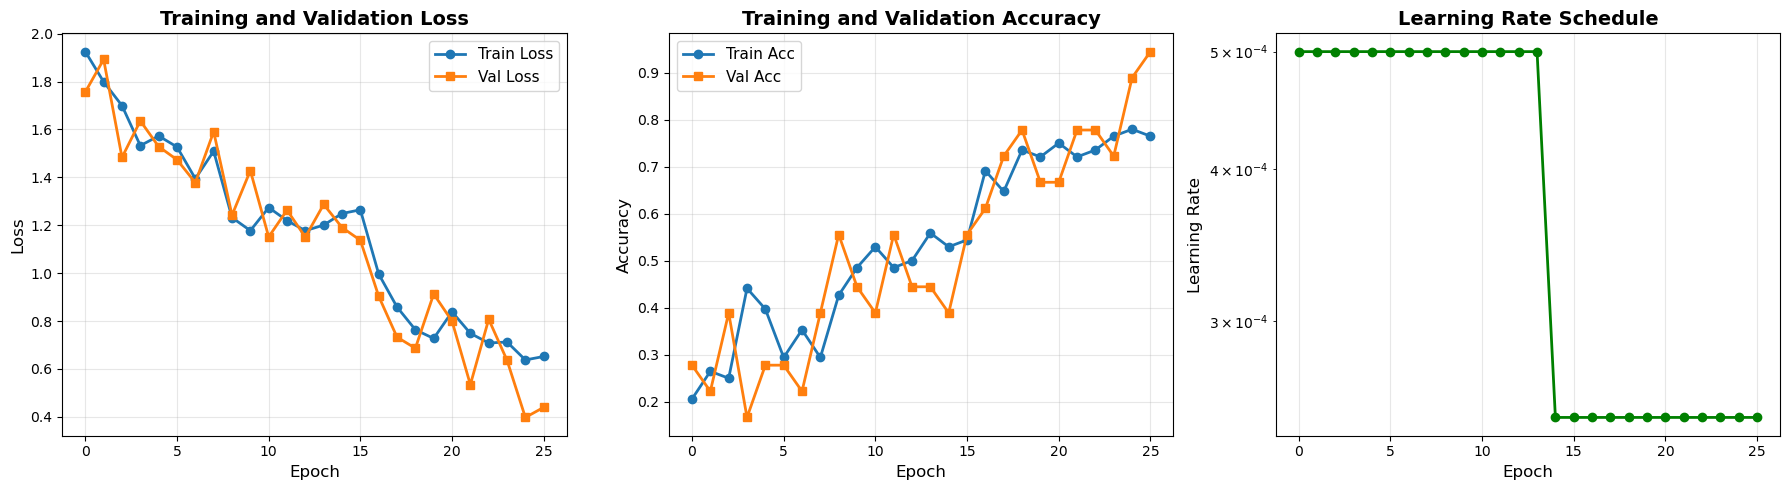

Training history saved


In [23]:
# Plot Training History
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Learning Rate
axes[2].plot(history['learning_rates'], marker='o', linewidth=2, color='green')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Learning Rate', fontsize=12)
axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gcn_tcn_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training history saved")

## Model Evaluation

In [24]:
# Load Best Model
checkpoint = torch.load('best_gcn_tcn_model.pth', map_location=config.DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])

print(f"Best model loaded from epoch {checkpoint['epoch']}")
print(f"Validation accuracy: {checkpoint['val_acc']:.4f}")
print(f"\nEvaluating on validation set...")

val_loss, val_acc, val_preds, val_labels = validate_epoch(
    model, val_loader, criterion, config.DEVICE
)

print(f"\nValidation Results:")
print(f"  Accuracy: {val_acc:.4f}")
print(f"  Loss: {val_loss:.4f}")

Best model loaded from epoch 26
Validation accuracy: 0.9444

Evaluating on validation set...



Validation Results:
  Accuracy: 0.9444
  Loss: 0.4398


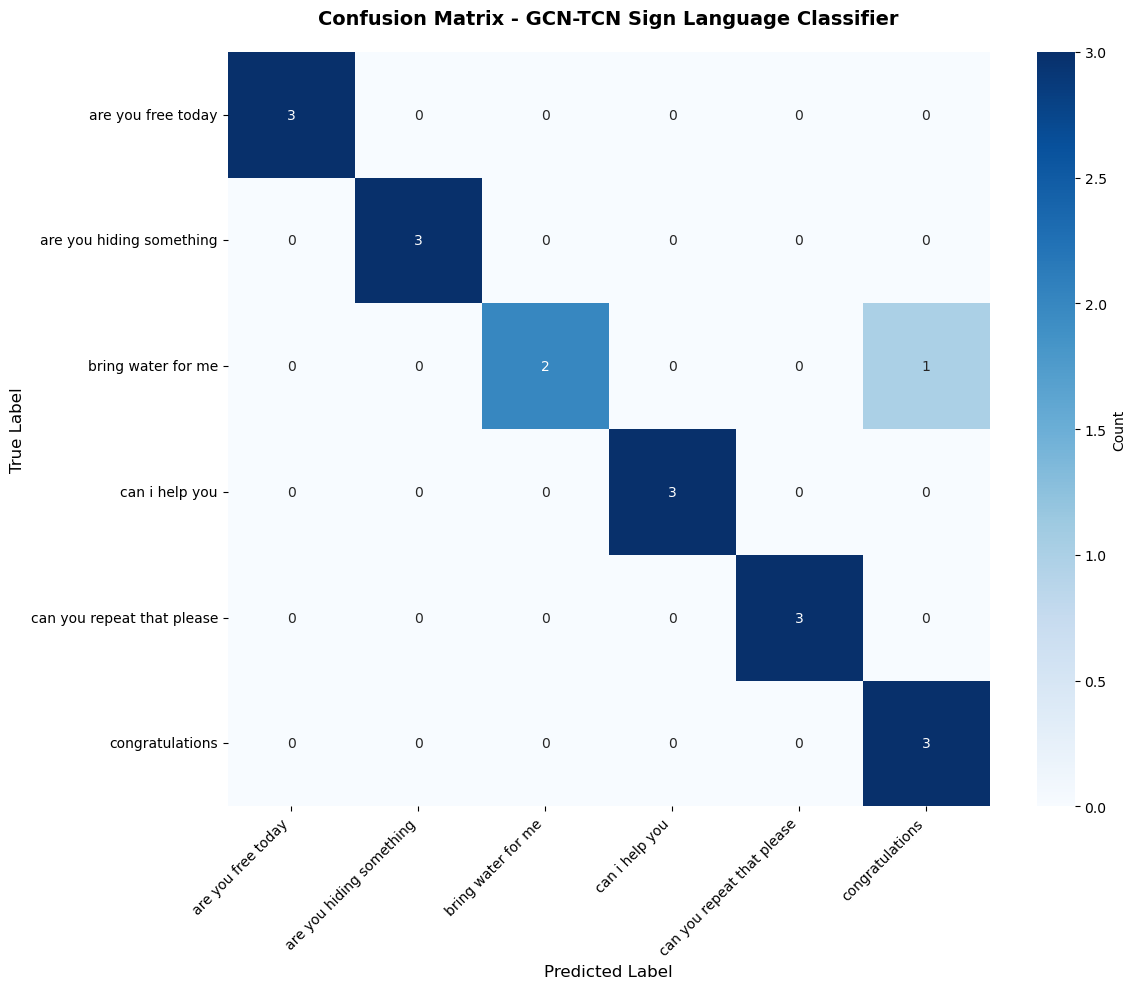

Confusion matrix saved


In [25]:
# Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[id2label[i] for i in range(num_classes)],
    yticklabels=[id2label[i] for i in range(num_classes)],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - GCN-TCN Sign Language Classifier', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('gcn_tcn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved")

In [26]:
# Classification Report
target_names = [id2label[i] for i in range(num_classes)]
report = classification_report(val_labels, val_preds, target_names=target_names, zero_division=0)

print("Classification Report:")
print("=" * 80)
print(report)

Classification Report:
                            precision    recall  f1-score   support

        are you free today       1.00      1.00      1.00         3
  are you hiding something       1.00      1.00      1.00         3
        bring water for me       1.00      0.67      0.80         3
            can i help you       1.00      1.00      1.00         3
can you repeat that please       1.00      1.00      1.00         3
           congratulations       0.75      1.00      0.86         3

                  accuracy                           0.94        18
                 macro avg       0.96      0.94      0.94        18
              weighted avg       0.96      0.94      0.94        18



In [27]:
# Per-Class Performance
print("\nPer-Class Performance Analysis:")
print("=" * 80)

class_correct = {}
class_total = {}

for true_label, pred_label in zip(val_labels, val_preds):
    class_total[true_label] = class_total.get(true_label, 0) + 1
    if true_label == pred_label:
        class_correct[true_label] = class_correct.get(true_label, 0) + 1

print(f"{'Class':<6} {'Sentence':<40} {'Accuracy':<12} {'Correct/Total'}")
print("-" * 80)

for class_id in sorted(class_total.keys()):
    sentence = id2label[class_id]
    total = class_total[class_id]
    correct = class_correct.get(class_id, 0)
    accuracy = (correct / total * 100) if total > 0 else 0.0
    
    print(f"{class_id:<6} {sentence:<40} {accuracy:>6.2f}%      {correct}/{total}")

print("-" * 80)

if class_total:
    accuracies = {i: (class_correct.get(i, 0)/class_total[i]*100) for i in class_total}
    best_class = max(accuracies, key=accuracies.get)
    worst_class = min(accuracies, key=accuracies.get)
    
    print(f"\nBest class:  [{best_class}] '{id2label[best_class]}' ({accuracies[best_class]:.1f}%)")
    print(f"Worst class: [{worst_class}] '{id2label[worst_class]}' ({accuracies[worst_class]:.1f}%)")


Per-Class Performance Analysis:
Class  Sentence                                 Accuracy     Correct/Total
--------------------------------------------------------------------------------
0      are you free today                       100.00%      3/3
1      are you hiding something                 100.00%      3/3
2      bring water for me                        66.67%      2/3
3      can i help you                           100.00%      3/3
4      can you repeat that please               100.00%      3/3
5      congratulations                          100.00%      3/3
--------------------------------------------------------------------------------

Best class:  [3] 'can i help you' (100.0%)
Worst class: [2] 'bring water for me' (66.7%)


## Inference Pipeline

In [28]:
# Inference Function
def predict_video(video_path, model, id2label, device, frame_skip=2, top_k=3):
    """
    Predict sign language sentence from video
    
    Args:
        video_path: Path to video file
        model: Trained model
        id2label: ID to label mapping
        device: Computation device
        frame_skip: Frame sampling rate
        top_k: Number of top predictions
    
    Returns:
        List of (sentence, confidence) tuples
    """
    model.eval()
    
    # Extract skeleton sequence
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    skeleton_seq = []
    frame_idx = 0
    
    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        enable_segmentation=False,
        refine_face_landmarks=False
    ) as holistic:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            if frame_idx % frame_skip != 0:
                frame_idx += 1
                continue
            
            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image.flags.writeable = False
            results = holistic.process(image)
            keypoints = extract_keypoints_from_frame(results)
            skeleton_seq.append(keypoints)
            frame_idx += 1
    
    cap.release()
    
    if len(skeleton_seq) == 0:
        raise ValueError("No keypoints extracted")
    
    # Prepare input
    skeleton_seq = np.stack(skeleton_seq)
    skeleton_seq = (skeleton_seq - 0.5) * 2.0
    skeleton_seq = skeleton_seq.astype(np.float32)
    
    # Convert to tensor
    skeleton_tensor = torch.from_numpy(skeleton_seq).unsqueeze(0).to(device)
    length_tensor = torch.tensor([skeleton_seq.shape[0]], dtype=torch.long).to(device)
    
    # Predict
    with torch.no_grad():
        logits = model(skeleton_tensor, length_tensor)
        probs = F.softmax(logits, dim=1)[0]
    
    # Get top-k predictions
    top_probs, top_indices = torch.topk(probs, min(top_k, len(id2label)))
    
    predictions = [
        (id2label[idx.item()], prob.item() * 100)
        for idx, prob in zip(top_indices, top_probs)
    ]
    
    return predictions

print("Inference function created")

Inference function created


In [29]:
# Test Inference on Sample
if len(val_dataset.video_paths) > 0:
    sample_idx = np.random.randint(0, len(val_dataset.video_paths))
    sample_video = val_dataset.video_paths[sample_idx]
    true_label_id = val_dataset.labels[sample_idx]
    true_label = id2label[true_label_id]
    
    print(f"Testing inference on validation sample")
    print("=" * 80)
    print(f"Video: {sample_video}")
    print(f"True Label: [{true_label_id}] {true_label}")
    print(f"\nTop predictions:")
    print("-" * 80)
    
    predictions = predict_video(sample_video, model, id2label, config.DEVICE)
    
    for rank, (sentence, confidence) in enumerate(predictions, 1):
        marker = ">>>" if sentence == true_label else "   "
        print(f"{marker} Rank {rank}: '{sentence}' - {confidence:.2f}%")
    
    result = "Correct" if predictions[0][0] == true_label else "Incorrect"
    print(f"\nResult: {result} prediction")

Testing inference on validation sample
Video: E:\College\Sem 6\Project\Computer Vision\Codes\Comp_data\bring water for me\bring water for me (4).MP4
True Label: [2] bring water for me

Top predictions:
--------------------------------------------------------------------------------
>>> Rank 1: 'bring water for me' - 40.85%
    Rank 2: 'congratulations' - 32.56%
    Rank 3: 'can you repeat that please' - 14.82%

Result: Correct prediction
